In [3]:
import gymnasium as gym
import panda_gym
from stable_baselines3 import DDPG
from stable_baselines3.common.evaluation import evaluate_policy


In [12]:
env_id = 'PandaPickAndPlace-v3'

# Create a vectorized environment. This is crucial for efficient training
# as it allows the agent to interact with multiple environments simultaneously.
# The `wrapper_class` is set to None as we don't need a specific wrapper here.
# TD3 is often more stable and robust for continuous control tasks than DDPG.
print(f"Creating environment: {env_id}")
env = gym.make(env_id,render_mode='rgb_array')
env.reset()

Creating environment: PandaPickAndPlace-v3


({'observation': array([ 3.8439669e-02, -2.1944723e-12,  1.9740014e-01,  0.0000000e+00,
         -0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -7.4994601e-02,
         -7.9296552e-02,  2.0000000e-02,  0.0000000e+00, -0.0000000e+00,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00], dtype=float32),
  'achieved_goal': array([-0.0749946 , -0.07929655,  0.02      ], dtype=float32),
  'desired_goal': array([-0.1319308 ,  0.00570883,  0.02      ], dtype=float32)},
 {'is_success': array(False)})

In [13]:
from stable_baselines3 import  PPO ,DDPG,TD3
total_timesteps = 500000
model_path = "./td3_panda_pick_and_place.zip" #"/content/drive/MyDrive/husob/06 ReinForcement Learning/007 ARM/ddpg_panda_pick_and_place.zip" #ppo-PandaPickAndPlace-v3-500000.zip" #f"ppo-{env_id}-{total_timesteps}"

# model = PPO.load(model_path)
model = TD3.load(model_path)

In [14]:
reward_history_before = []
reward_history_after = []  
episodes = 32


for episode in range(episodes):
    obs, info = env.reset()
    done = False
    total_reward_before = 0
    while not done:
        action = env.action_space.sample() 
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward_before += reward
        if terminated or truncated:
            done = True
    reward_history_before.append(total_reward_before)
    print(f"Episode: {episode + 1}, Total Reward Before: {total_reward_before}")

print(f"Average Reward Before: {sum(reward_history_before) / episodes}")

Episode: 1, Total Reward Before: -50.0
Episode: 2, Total Reward Before: -50.0
Episode: 3, Total Reward Before: -50.0
Episode: 4, Total Reward Before: -50.0
Episode: 5, Total Reward Before: -50.0
Episode: 6, Total Reward Before: -50.0
Episode: 7, Total Reward Before: -50.0
Episode: 8, Total Reward Before: -50.0
Episode: 9, Total Reward Before: -50.0
Episode: 10, Total Reward Before: -50.0
Episode: 11, Total Reward Before: -50.0
Episode: 12, Total Reward Before: -50.0
Episode: 13, Total Reward Before: -50.0
Episode: 14, Total Reward Before: -50.0
Episode: 15, Total Reward Before: -50.0
Episode: 16, Total Reward Before: -50.0
Episode: 17, Total Reward Before: -50.0
Episode: 18, Total Reward Before: -50.0
Episode: 19, Total Reward Before: -50.0
Episode: 20, Total Reward Before: -50.0
Episode: 21, Total Reward Before: -50.0
Episode: 22, Total Reward Before: -50.0
Episode: 23, Total Reward Before: -50.0
Episode: 24, Total Reward Before: -50.0
Episode: 25, Total Reward Before: -50.0
Episode: 

In [7]:

for episode in range(episodes):
    obs, info = env.reset()
    done = False
    total_reward_after = 0
    while not done:
        action,_ = model.predict(obs,deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward_after += reward
        if terminated or truncated:
            done = True
    reward_history_after.append(total_reward_after)
    print(f"Episode: {episode + 1}, Total Reward after: {total_reward_after}")

print(f"Average Reward after: {sum(reward_history_after) / episodes}")

Episode: 1, Total Reward after: -50.0
Episode: 2, Total Reward after: 0.0
Episode: 3, Total Reward after: -50.0
Episode: 4, Total Reward after: -50.0
Episode: 5, Total Reward after: -50.0
Episode: 6, Total Reward after: -50.0
Episode: 7, Total Reward after: -50.0
Episode: 8, Total Reward after: -50.0
Episode: 9, Total Reward after: -50.0
Episode: 10, Total Reward after: -50.0
Episode: 11, Total Reward after: -50.0
Episode: 12, Total Reward after: -50.0
Episode: 13, Total Reward after: -50.0
Episode: 14, Total Reward after: -50.0
Episode: 15, Total Reward after: -50.0
Episode: 16, Total Reward after: -50.0
Episode: 17, Total Reward after: -50.0
Episode: 18, Total Reward after: -50.0
Episode: 19, Total Reward after: -50.0
Episode: 20, Total Reward after: -50.0
Episode: 21, Total Reward after: -50.0
Episode: 22, Total Reward after: -50.0
Episode: 23, Total Reward after: -50.0
Episode: 24, Total Reward after: -50.0
Episode: 25, Total Reward after: -50.0
Episode: 26, Total Reward after: -50

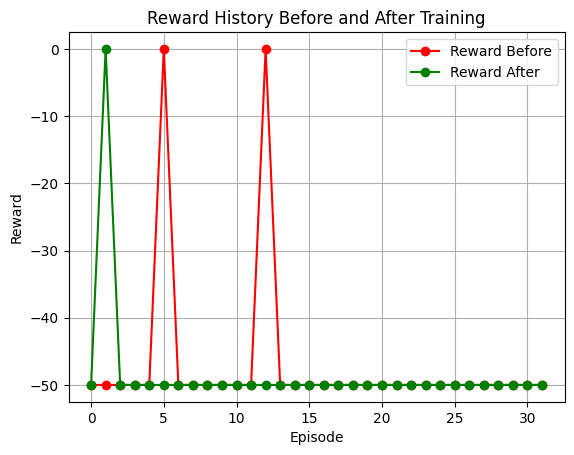

In [8]:
import matplotlib.pyplot as plt

plt.plot(reward_history_before, label='Reward Before', color='red', linestyle='-',marker='o')
plt.plot(reward_history_after, label='Reward After', color='green', linestyle='-',marker='o')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Reward History Before and After Training')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from numpngw import write_apng 

In [11]:
images = [] 
total_reward = 0 

obs ,info = env.reset()
images.append(env.render())
done = False 
while not done:
  action,_ = model.predict(obs,deterministic=True)
  obs,reward,terminated,truncated,info = env.step(action)
  images.append(env.render())

  total_reward += reward 
  if terminated or truncated:
    break 
print(f"Total Reward: {total_reward}")
write_apng(f'output-{env_id}.png',images,delay=500)

Total Reward: -50.0
